<a href="https://colab.research.google.com/github/stephenkeyy77/ECON3916-Statistical-Machine-Learning/blob/main/Final%20Project/ECON%203916%3A%20ML%20Prediction%20Project%20%E2%80%94%20Final%20Project%20-%20deliverble%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [1]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we predict the hourly demand for rental bikes in Washington D.C. using weather conditions, time-of-day, and calendar features?

**This is a prediction (umbrella) problem because:**
We are forecasting a continuous count (number of bike rentals per hour) from observable environmental and temporal features. We are not asking "does temperature cause people to ride bikes" — only whether we can accurately forecast demand before it happens.

**The decision this enables:**
City transportation planners and bike-share operators (e.g., Capital Bikeshare) can use this model to decide how many bikes to deploy at each station for each hour — reducing shortages during peak demand and avoiding over-supply during low-demand periods, optimizing operational costs and rider satisfaction.

**Dataset:**
- **Source:** https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset
- **N =** 17379
- **Features =** 13
- **Target variable =** cnt (total bike rentals per hour)
- **Access date:** 12/19/2013

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [2]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

df = pd.read_csv('https://raw.githubusercontent.com/stephenkeyy77/ECON3916-Statistical-Machine-Learning/refs/heads/main/Final%20Project/Data/hour.csv')



# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (17379, 17)
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### 2.2 Basic Description

In [3]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
Series([], dtype: float64)
=== MISSING DATA AUDIT ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Total missing cells: 0 / 295,443


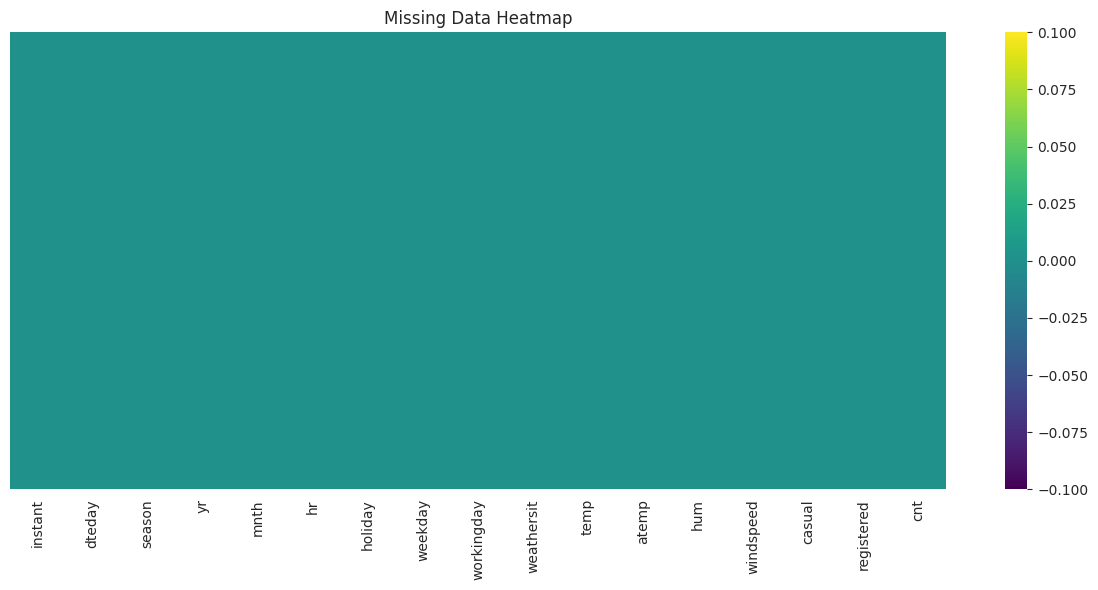

In [6]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

print("=== MISSING DATA AUDIT ===")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()} / {df.shape[0] * df.shape[1]:,}")

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** No missing values were detected across all 17 columns (17,379 non-null for every feature). Since the dataset is complete, no imputation or dropping is required. MCAR/MAR/MNAR classification is not applicable. However, the dataset does contain "unknown" as a category in `weathersit` (value 4, representing extreme weather) which appears in only 1 record — this is not technically missing data but rather a rare event that will be retained.

(Is this MCAR, MAR, or MNAR? What will you do — drop, impute, or flag?)

### 2.4 Distribution Plots

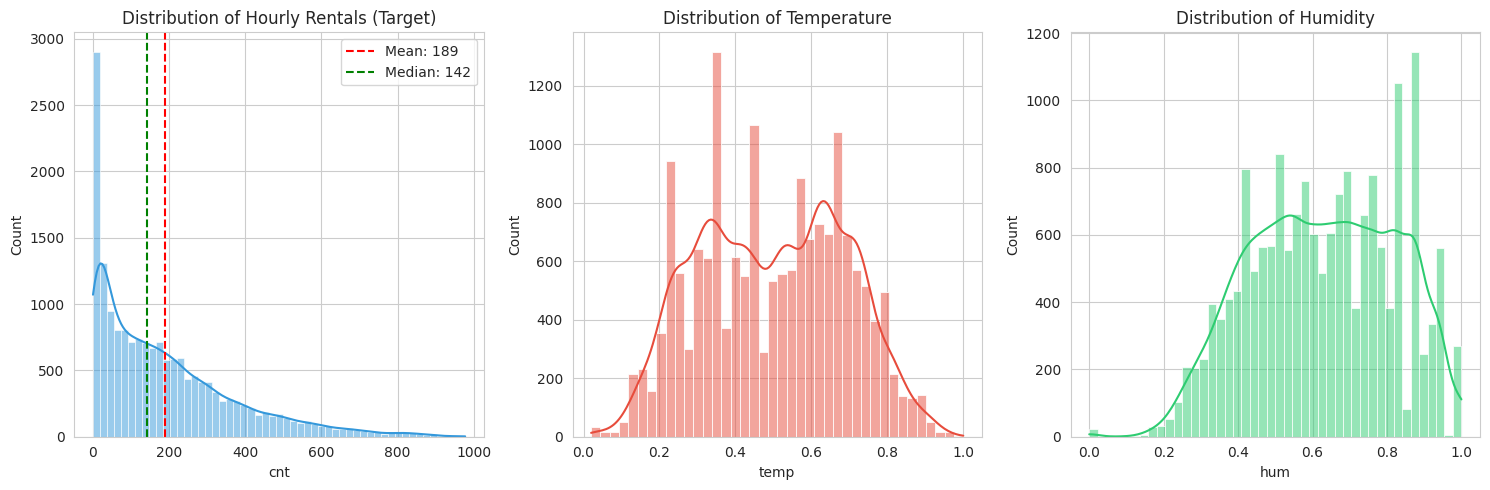

Target (cnt) — Mean: 189.5, Median: 142.0, Skewness: 1.28


In [7]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Target variable: cnt
sns.histplot(df['cnt'], kde=True, ax=axes[0], color='#3498db')
axes[0].axvline(df['cnt'].mean(), color='red', linestyle='--', label=f"Mean: {df['cnt'].mean():.0f}")
axes[0].axvline(df['cnt'].median(), color='green', linestyle='--', label=f"Median: {df['cnt'].median():.0f}")
axes[0].set_title('Distribution of Hourly Rentals (Target)')
axes[0].legend()

# Key feature 1: temp
sns.histplot(df['temp'], kde=True, ax=axes[1], color='#e74c3c')
axes[1].set_title('Distribution of Temperature')

# Key feature 2: hum
sns.histplot(df['hum'], kde=True, ax=axes[2], color='#2ecc71')
axes[2].set_title('Distribution of Humidity')

plt.tight_layout()
plt.show()

print(f"Target (cnt) — Mean: {df['cnt'].mean():.1f}, Median: {df['cnt'].median():.1f}, Skewness: {df['cnt'].skew():.2f}")

### 2.5 Outlier Detection

In [8]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

# Check outliers for target and key features
for col in ['cnt', 'temp', 'hum', 'windspeed']:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%) | Fences: [{lower:.2f}, {upper:.2f}]')

cnt: 505 outliers (2.9%) | Fences: [-321.50, 642.50]
temp: 0 outliers (0.0%) | Fences: [-0.14, 1.14]
hum: 22 outliers (0.1%) | Fences: [0.03, 1.23]
windspeed: 342 outliers (2.0%) | Fences: [-0.12, 0.48]


**Outlier strategy:** Keep with justification. The outliers in `cnt` represent real peak-hour demand (rush hour, good weather days) — they are not data errors but genuine high-demand events that the model needs to learn to predict. Trimming them would remove the exact patterns we want to capture. Outliers in `windspeed` and `hum` are also real weather observations. No winsorizing or trimming applied.
(Trim? Winsorize? Keep with justification?)

### 2.6 Correlations

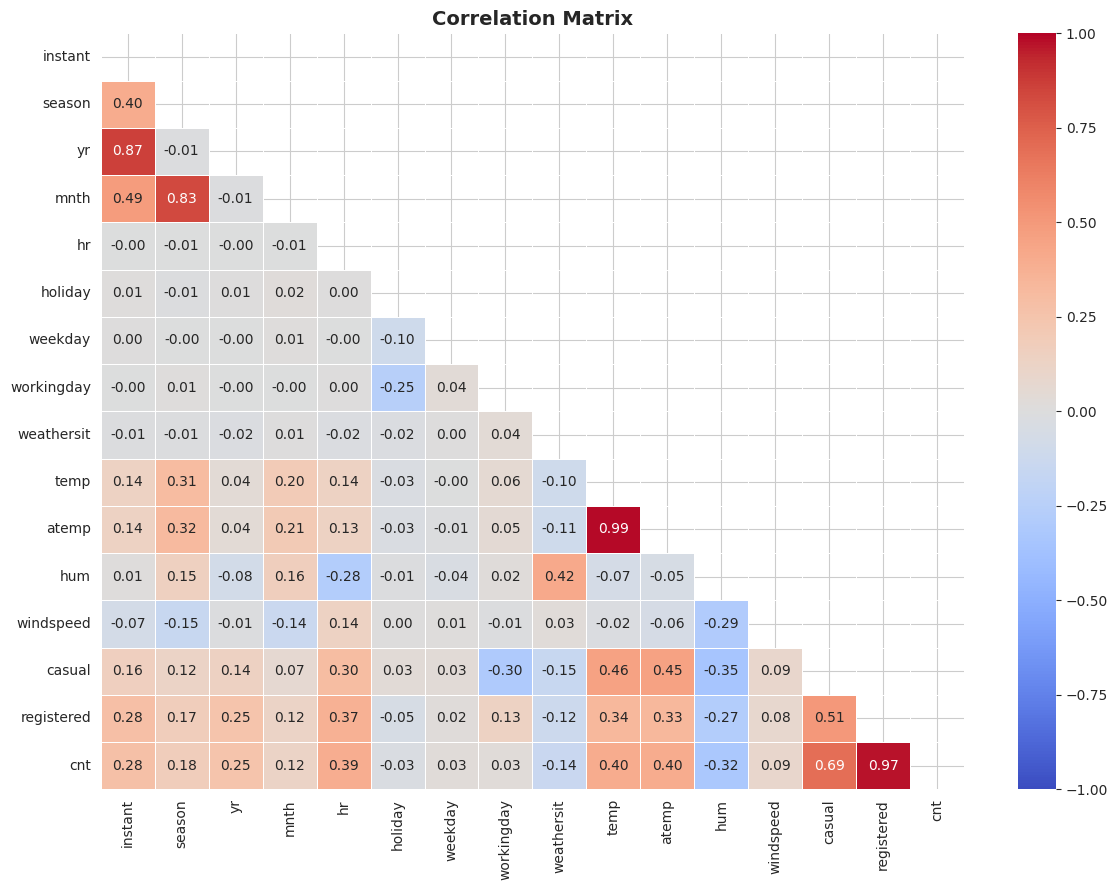

temp vs atemp correlation: 0.988 → High multicollinearity, drop atemp
temp vs cnt correlation: 0.405 → Temperature is a strong predictor
hr vs cnt correlation: 0.394 → Hour of day matters


In [9]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"temp vs atemp correlation: {df['temp'].corr(df['atemp']):.3f} → High multicollinearity, drop atemp")
print(f"temp vs cnt correlation: {df['temp'].corr(df['cnt']):.3f} → Temperature is a strong predictor")
print(f"hr vs cnt correlation: {df['hr'].corr(df['cnt']):.3f} → Hour of day matters")

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable `cnt` is right-skewed (skewness = 1.28) and does not follow a normal distribution. The mean (189) is greater than the median (142), and due to peak-hour demand, the distribution exhibits a long right tail. Since this is a regression problem and we are using a tree-based model (Random Forest), which is robust to skewness, data transformation is strictly speaking not required.


2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer: The strongest predictors of cnt are: temp/atemp (0.40), hr (0.39), season (0.18), and hum (-0.32, negative). However, temp and atemp are correlated at 0.99 — severe multicollinearity.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:*  The biggest issue is multicollinearity between temp and atemp (r = 0.99); we will drop atemp to avoid inflating coefficient variance.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 17379**
observations and **M = 13** features.

**Missing data:** 0% of cells are missing. No missingness pattern applies

**Outliers:** I identified 505 outliers in `cnt` (2.9%) and 342 in `windspeed` (2.0%) using  IQR . I will handle them by keeping them.

**Target variable:** `cnt` is right-skewed (skewness = 1.28), ranging from 1 to 977 rentals per hour. Mean (189) > Median (142), indicating concentration at lower values with a long right tail from rush-hour peaks..

**Key finding from EDA:** `temp` and `atemp` have 0.99 correlation, so `atemp` will be dropped to avoid multicollinearity. The strongest predictors of hourly demand are `temp` (r = 0.40), `hr` (r = 0.39), and `hum` (r = -0.32).

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [10]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# Define features and target
# Drop: instant (index), dteday (date string), casual & registered (leakage), atemp (multicollinearity)
X = df.drop(columns=['instant', 'dteday', 'casual', 'registered', 'cnt', 'atemp'])
y = df['cnt']

# For regression: no stratify needed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'\nFeatures ({X.shape[1]}): {list(X.columns)}')

Train: 13903 samples
Test:  3476 samples

Features (11): ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed']


### 3.2 Model 1: Baseline

In [11]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
# Regression: LinearRegression as baseline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

# Regression metrics
print('Model 1: Linear Regression (Baseline)')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

Model 1: Linear Regression (Baseline)
RMSE: 139.4367
MAE:  104.9795
R2:   0.3860


### 3.3 Model 2: Your Choice

In [ ]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
# Choose a more flexible model:
#   Classification: RandomForestClassifier, GradientBoostingClassifier
#   Regression: RandomForestRegressor, GradientBoostingRegressor

# from sklearn.ensemble import RandomForestClassifier  # or RandomForestRegressor
#
# model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
# model_2.fit(X_train, y_train)
#
# y_pred_2 = model_2.predict(X_test)
#
# print('Model 2: Random Forest')
# print(classification_report(y_test, y_pred_2))

### 3.4 Cross-Validation Comparison

In [ ]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# # Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
# #                  'neg_mean_squared_error', 'r2' (regression)
# scoring = 'accuracy'
#
# cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
# cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
#
# print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
# print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
#
# # Comparison table
# comparison = pd.DataFrame({
#     'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
#     f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
#     f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
# })
# comparison

---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
#
# fig, ax = plt.subplots(figsize=(8, 6))
# importances.plot(kind='barh', ax=ax, color='steelblue')
# ax.set_xlabel('Feature Importance (Gini)')
# ax.set_title('Feature Importance — Predictive, NOT Causal')
#
# # CRITICAL: Add the caveat banner
# ax.text(
#     0.98, 0.02,
#     'Predictive importance only.\nDoes not imply causal effect.',
#     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
#     style='italic', color='#c0392b',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
# )
#
# plt.tight_layout()
# plt.show()

### 4.2 Key Visualization for Your Report

In [ ]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___